# HomeCoach 2023-2026 Analysis

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## Load All HomeCoach Datasets

In [ ]:
datasets = {
    'HomeCoach 2023': pd.read_csv('../../data/raw/HomeCoach_5min_2023.csv'),
    'HomeCoach 2024': pd.read_csv('../../data/raw/HomeCoach_5min_2024.csv'),
    'HomeCoach 2025': pd.read_csv('../../data/raw/HomeCoach_5min_2025.csv'),
    'HomeCoach 2026': pd.read_csv('../../data/raw/HomeCoach_5min_2026.csv'),
}

for name, df in datasets.items():
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    print(
        f"{name}: shape={df.shape}, "
        f"from {df['timestamp'].min()} to {df['timestamp'].max()}"
    )

HomeCoach 2023: shape=(77045, 6), from 2023-03-04 09:12:50 to 2023-12-31 23:59:31
HomeCoach 2024: shape=(100325, 6), from 2024-01-01 00:02:30 to 2024-12-31 23:54:31
HomeCoach 2025: shape=(100190, 6), from 2025-01-01 00:02:30 to 2025-12-31 23:59:31
HomeCoach 2026: shape=(34132, 6), from 2026-01-01 00:02:30 to 2026-05-06 15:47:49


## First Rows

In [6]:
for name, df in datasets.items():
    print(f'First 5 rows of {name}:')
    display(df.head())

First 5 rows of HomeCoach 2023:


,timestamp,Temperature,Humidity,CO2,Noise,Pressure
0,2023-03-04 09:12:50,17.7,56,2305,67,1006.6
1,2023-03-04 09:17:50,17.9,56,2250,73,1006.6
2,2023-03-04 09:22:50,18.3,57,2286,77,1006.4
3,2023-03-04 09:27:50,18.9,57,2266,58,1006.4
4,2023-03-04 09:32:50,19.1,57,2238,54,1006.3


First 5 rows of HomeCoach 2024:


,timestamp,Temperature,Humidity,CO2,Noise,Pressure
0,2024-01-01 00:02:30,19.5,51,1418,43,999.3
1,2024-01-01 00:07:30,19.5,51,1432,39,999.3
2,2024-01-01 00:12:30,19.5,51,1418,35,999.4
3,2024-01-01 00:17:30,19.5,51,1418,33,999.4
4,2024-01-01 00:22:30,19.4,51,1404,34,999.4


First 5 rows of HomeCoach 2025:


,timestamp,Temperature,Humidity,CO2,Noise,Pressure
0,2025-01-01 00:02:30,18.5,49,1529,47,1020.7
1,2025-01-01 00:07:30,18.5,49,1515,50,1020.7
2,2025-01-01 00:12:30,18.5,49,1518,48,1020.7
3,2025-01-01 00:17:30,18.5,49,1512,47,1020.7
4,2025-01-01 00:22:30,18.4,49,1501,47,1020.7


First 5 rows of HomeCoach 2026:


,timestamp,Temperature,Humidity,CO2,Noise,Pressure
0,2026-01-01 00:02:30,18.4,56,1760,47,1007.6
1,2026-01-01 00:12:30,18.3,56,1762,39,1007.5
2,2026-01-01 00:17:30,18.3,57,1722,34,1007.5
3,2026-01-01 00:22:30,18.2,57,1793,32,1007.6
4,2026-01-01 00:27:30,18.2,57,1731,35,1007.5


## Column Presence Across Years

In [7]:
all_columns = sorted(set().union(*(df.columns for df in datasets.values())))

presence = pd.DataFrame(
    {
        name: [col in df.columns for col in all_columns]
        for name, df in datasets.items()
    },
    index=all_columns
)

presence['Count'] = presence.sum(axis=1)
presence['Sharedness'] = presence['Count'].map({
    4: 'shared by all years',
    3: 'shared by most years',
    2: 'shared by some years',
    1: 'unique to one year',
})

pretty_presence = presence.copy()
for name in datasets:
    pretty_presence[name] = pretty_presence[name].map({True: 'Yes', False: 'No'})

pretty_presence.sort_values(by=['Count'], ascending=False)

,HomeCoach 2023,HomeCoach 2024,HomeCoach 2025,HomeCoach 2026,Count,Sharedness
CO2,Yes,Yes,Yes,Yes,4,shared by all years
Humidity,Yes,Yes,Yes,Yes,4,shared by all years
Noise,Yes,Yes,Yes,Yes,4,shared by all years
Pressure,Yes,Yes,Yes,Yes,4,shared by all years
Temperature,Yes,Yes,Yes,Yes,4,shared by all years
timestamp,Yes,Yes,Yes,Yes,4,shared by all years


## Quick Structural Overview

In [8]:
overview = pd.DataFrame({
    name: {
        'Rows': df.shape[0],
        'Columns': df.shape[1],
        'Missing values': int(df.isna().sum().sum()),
        'Duplicate rows': int(df.duplicated().sum()),
        'Start timestamp': df['timestamp'].min(),
        'End timestamp': df['timestamp'].max(),
    }
    for name, df in datasets.items()
}).T

display(overview)

,Rows,Columns,Missing values,Duplicate rows,Start timestamp,End timestamp
HomeCoach 2023,77045,6,0,0,2023-03-04 09:12:50,2023-12-31 23:59:31
HomeCoach 2024,100325,6,0,0,2024-01-01 00:02:30,2024-12-31 23:54:31
HomeCoach 2025,100190,6,0,0,2025-01-01 00:02:30,2025-12-31 23:59:31
HomeCoach 2026,34132,6,0,0,2026-01-01 00:02:30,2026-05-06 15:47:49


## Per-Year Feature Ranges

In [9]:
for name, df in datasets.items():
    print(f'{name} Ranges:')
    display(df.describe(include='all'))

HomeCoach 2023 Ranges:


,timestamp,Temperature,Humidity,CO2,Noise,Pressure
count,77045,77045.000000,77045.000000,77045.000000,77045.000000,77045.000000
mean,2023-08-10 08:33:23.757297,23.139997,50.883094,905.632436,40.118658,1002.949854
min,2023-03-04 09:12:50,15.700000,29.000000,338.000000,31.000000,972.400000
25%,2023-05-28 14:33:19,20.200000,47.000000,521.000000,32.000000,999.400000
50%,2023-08-14 12:33:45,22.800000,51.000000,730.000000,35.000000,1003.800000
75%,2023-10-23 16:39:08,26.100000,55.000000,1221.000000,45.000000,1007.400000
max,2023-12-31 23:59:31,31.500000,69.000000,5000.000000,83.000000,1030.400000
std,NaN,3.212124,5.765029,466.235452,10.671247,7.205692


HomeCoach 2024 Ranges:


,timestamp,Temperature,Humidity,CO2,Noise,Pressure
count,100325,100325.000000,100325.000000,100325.000000,100325.000000,100325.000000
mean,2024-07-01 22:35:23.013905,22.032804,50.897563,841.479372,40.495131,1004.306569
min,2024-01-01 00:02:30,15.600000,27.000000,333.000000,31.000000,978.000000
25%,2024-04-01 11:03:00,19.300000,47.000000,524.000000,32.000000,999.000000
50%,2024-07-02 05:23:31,21.000000,51.000000,708.000000,38.000000,1003.800000
75%,2024-09-30 17:49:01,24.100000,55.000000,1067.000000,46.000000,1009.700000
max,2024-12-31 23:54:31,31.600000,72.000000,4270.000000,80.000000,1026.600000
std,NaN,3.545550,6.733731,401.687417,9.150146,8.076195


HomeCoach 2025 Ranges:


,timestamp,Temperature,Humidity,CO2,Noise,Pressure
count,100190,100190.000000,100190.000000,100190.000000,100190.000000,100190.000000
mean,2025-07-02 06:04:16.476604,22.084842,52.286216,925.639565,41.184360,1005.036278
min,2025-01-01 00:02:30,16.000000,31.000000,330.000000,31.000000,979.100000
25%,2025-04-01 13:24:15,19.200000,48.000000,563.000000,32.000000,1000.900000
50%,2025-07-02 20:41:00,21.000000,53.000000,770.000000,40.000000,1004.800000
75%,2025-10-01 13:37:46,25.100000,57.000000,1213.000000,47.000000,1009.100000
max,2025-12-31 23:59:31,31.000000,72.000000,2757.000000,81.000000,1025.300000
std,NaN,3.578954,6.577149,452.126106,9.155842,6.612797


HomeCoach 2026 Ranges:


,timestamp,Temperature,Humidity,CO2,Noise,Pressure
count,34132,34132.000000,34132.000000,34132.000000,34132.000000,34132.000000
mean,2026-03-04 18:36:51.944655,20.097363,51.843197,1230.777745,39.865874,1001.485808
min,2026-01-01 00:02:30,15.800000,24.000000,329.000000,31.000000,973.900000
25%,2026-02-01 09:31:25,18.800000,48.000000,759.000000,32.000000,995.300000
50%,2026-03-04 19:25:20,19.900000,52.000000,1212.000000,36.000000,1003.000000
75%,2026-04-05 00:28:54,21.400000,56.000000,1614.000000,45.000000,1008.800000
max,2026-05-06 15:47:49,25.200000,68.000000,3329.000000,81.000000,1016.700000
std,NaN,1.907361,6.284013,530.860647,9.032335,9.026684


## Correlation Matrices

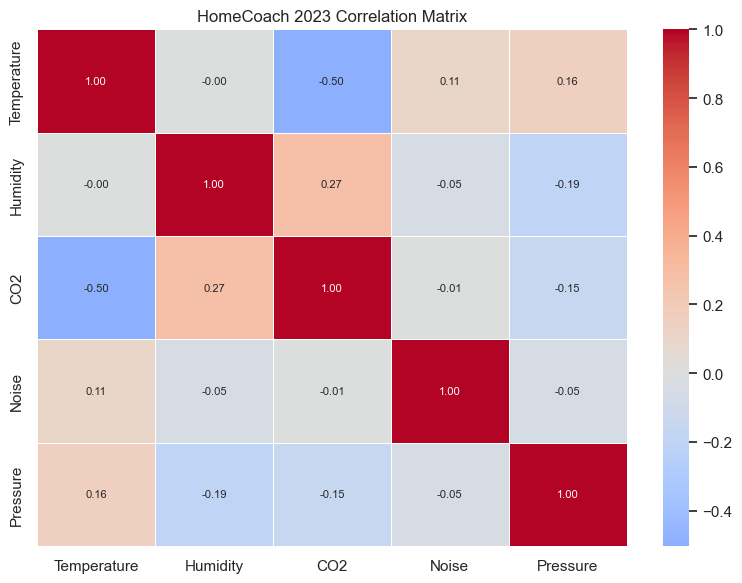

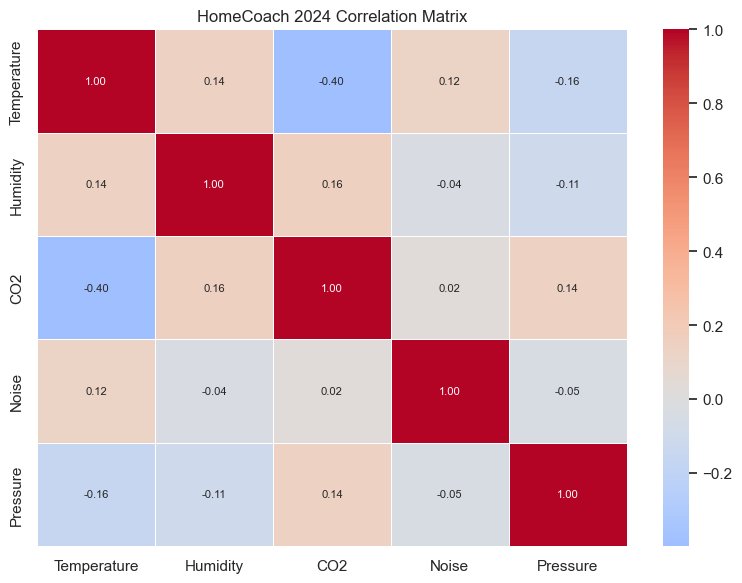

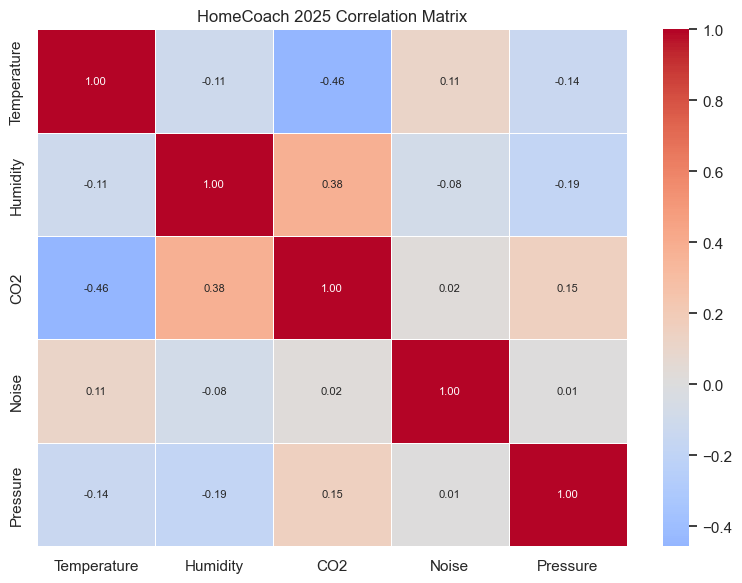

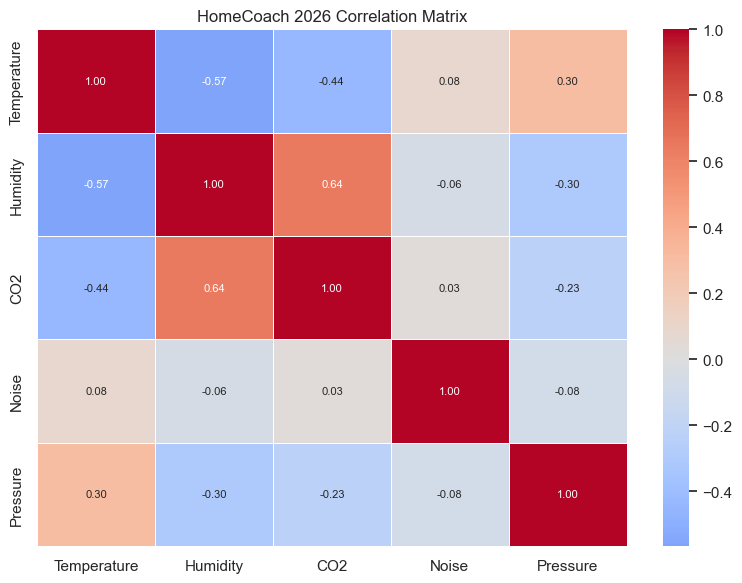

In [10]:
for name, df in datasets.items():
    numeric_df = df.select_dtypes(include=np.number)

    if numeric_df.empty:
        print(f'{name} has no numeric columns for correlation.')
        continue

    corr = numeric_df.corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        cmap='coolwarm',
        center=0,
        linewidths=0.5,
        annot=True,
        fmt='.2f',
        annot_kws={'size': 8},
    )
    plt.title(f'{name} Correlation Matrix')
    plt.tight_layout()
    plt.show()

## Numeric Feature Comparison

In [11]:
numeric_summary = []

for dataset_name, df in datasets.items():
    numeric_df = df.select_dtypes(include=np.number)

    for column in numeric_df.columns:
        numeric_summary.append({
            'Dataset': dataset_name,
            'Feature': column,
            'Min': numeric_df[column].min(),
            'Median': numeric_df[column].median(),
            'Mean': numeric_df[column].mean(),
            'Max': numeric_df[column].max(),
            'Std': numeric_df[column].std(),
        })

numeric_summary = pd.DataFrame(numeric_summary)
display(numeric_summary.sort_values(by=['Feature', 'Dataset']).reset_index(drop=True))

,Dataset,Feature,Min,Median,Mean,Max,Std
0,HomeCoach 2023,CO2,338.0,730.0,905.632436,5000.0,466.235452
1,HomeCoach 2024,CO2,333.0,708.0,841.479372,4270.0,401.687417
2,HomeCoach 2025,CO2,330.0,770.0,925.639565,2757.0,452.126106
3,HomeCoach 2026,CO2,329.0,1212.0,1230.777745,3329.0,530.860647
4,HomeCoach 2023,Humidity,29.0,51.0,50.883094,69.0,5.765029
5,HomeCoach 2024,Humidity,27.0,51.0,50.897563,72.0,6.733731
6,HomeCoach 2025,Humidity,31.0,53.0,52.286216,72.0,6.577149
7,HomeCoach 2026,Humidity,24.0,52.0,51.843197,68.0,6.284013
8,HomeCoach 2023,Noise,31.0,35.0,40.118658,83.0,10.671247
9,HomeCoach 2024,Noise,31.0,38.0,40.495131,80.0,9.150146


## Visual Anomaly Detection

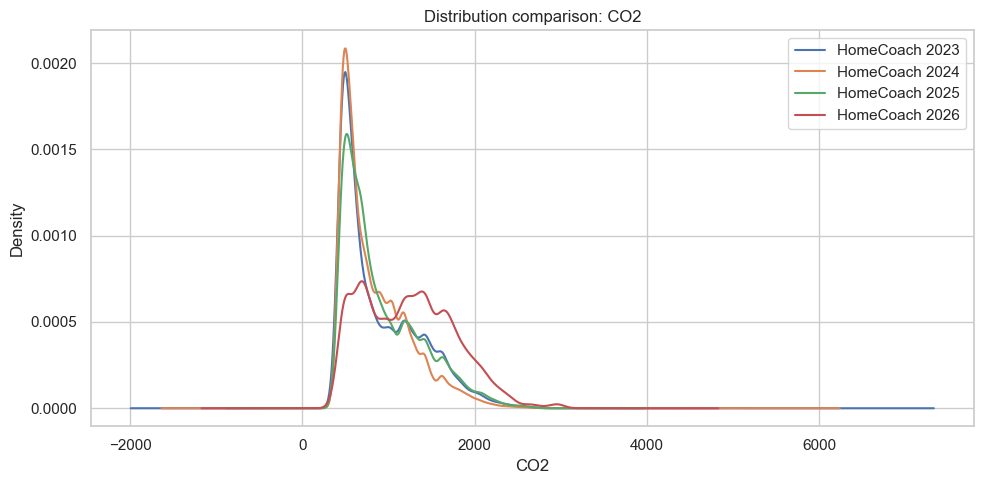

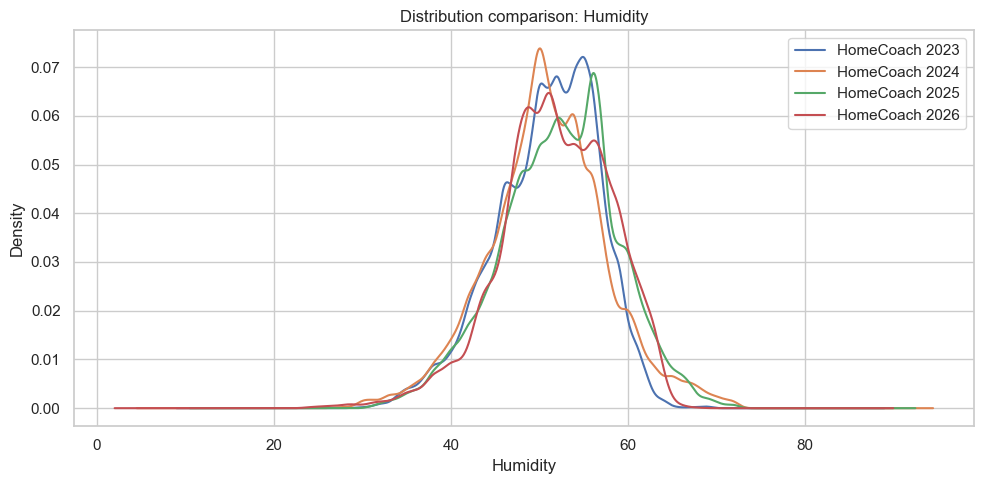

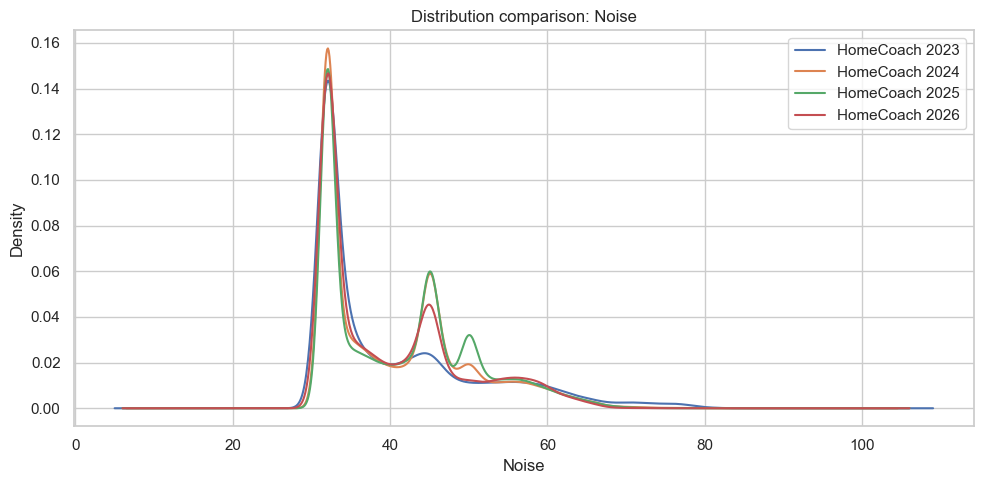

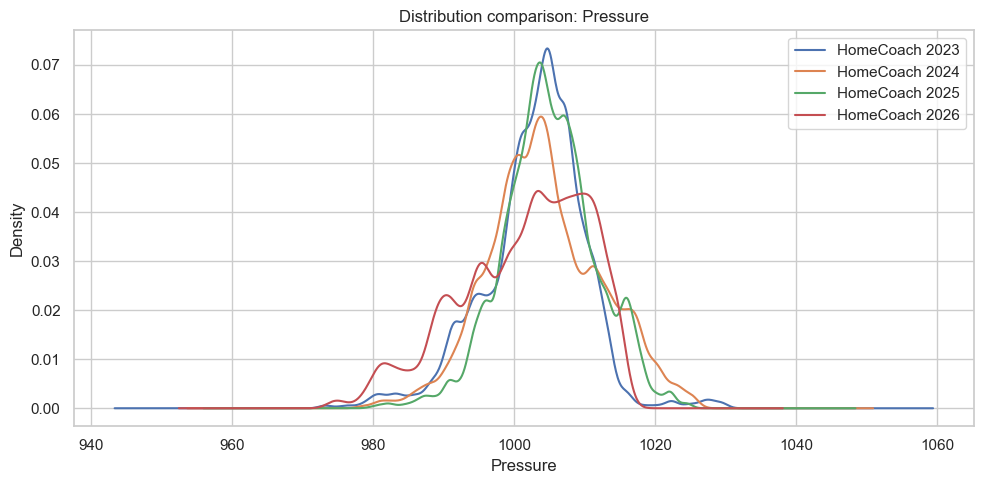

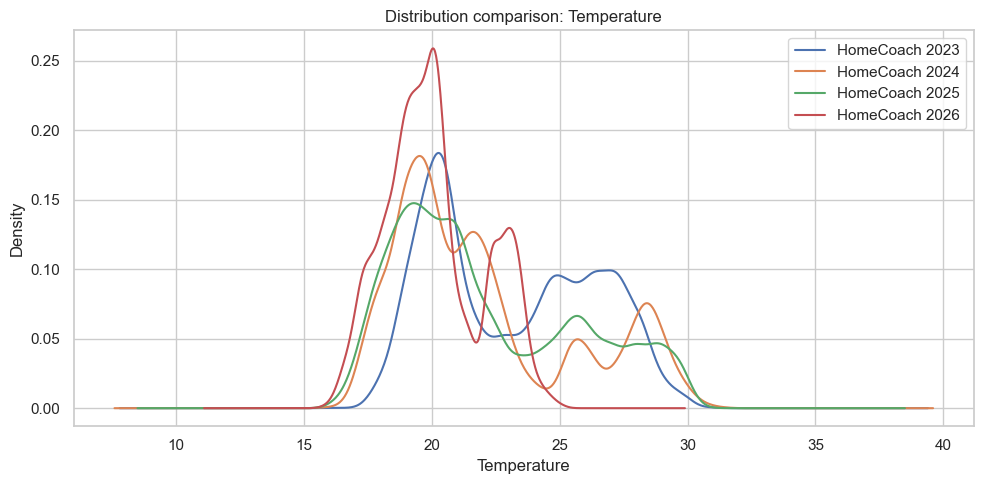

In [12]:
numeric_features = sorted(set(
    col
    for df in datasets.values()
    for col in df.select_dtypes(include=np.number).columns
))

for feature in numeric_features:
    plt.figure(figsize=(10, 5))

    found = False

    for name, df in datasets.items():
        if feature in df.columns:
            df[feature].dropna().plot(kind='kde', label=name)
            found = True

    if found:
        plt.title(f'Distribution comparison: {feature}')
        plt.xlabel(feature)
        plt.legend()
        plt.tight_layout()
        plt.show()